<a href="https://colab.research.google.com/github/RaselParvejHrid/machine-learning/blob/main/with-chatgpt/001%20KNN/project002/project002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metadata

[Project Details](https://github.com/RaselParvejHrid/machine-learning/tree/main/with-chatgpt/001%20KNN/project005)

Started on Jul 08, 2026

Completed on Jul 08, 2026

# Lib Imports

In [22]:

import numpy as np
import pandas as pd
from matplotlib.figure import Figure
from IPython.display import display
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Loading the Dataset as SKLearn#Bunch

In [2]:
print(load_wine().DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

This claims that there is no attribute value missing. The number of samples is 178. There are 13 predictive numeric features, and a target class with 3 values in its domain.

Still I will check these again with Pandas#Dataframe API.

Also, the feature values have variying min-max range. And as my algorithm here will be KNN that is distance-based, scaling of features is must.



# Loading the Dataset as Pandas#Dataframe

In [ ]:
dataset = load_wine(as_frame=True).frame

In [4]:
dataset

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


# EDA

## Analytical View of the Dataset

### Dataset Shape

In [5]:
n_rows, n_columns = dataset.shape

In [6]:
print(f"The dataset has\n{n_rows} samples\nand {n_columns} columns.")

The dataset has
178 samples
and 14 columns.


Out of 14 columns, 'target' is a categorical target and, other 13 columns are numeric features.

### Dataset Info

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

### Statistical Profiling

In [ ]:
dataset.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Features has varying min-max ranges. Yes, scaling of features is a must.

### Samples

In [9]:
dataset.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0


In [10]:
dataset.tail(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
168,13.58,2.58,2.69,24.5,105.0,1.55,0.84,0.39,1.54,8.660000,0.74,1.80,750.0,2
169,13.40,4.60,2.86,25.0,112.0,1.98,0.96,0.27,1.11,8.500000,0.67,1.92,630.0,2
170,12.20,3.03,2.32,19.0,96.0,1.25,0.49,0.40,0.73,5.500000,0.66,1.83,510.0,2
171,12.77,2.39,2.28,19.5,86.0,1.39,0.51,0.48,0.64,9.899999,0.57,1.63,470.0,2
172,14.16,2.51,2.48,20.0,91.0,1.68,0.70,0.44,1.24,9.700000,0.62,1.71,660.0,2
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.700000,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.300000,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.200000,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.300000,0.60,1.62,840.0,2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.200000,0.61,1.60,560.0,2


In [11]:
dataset.sample(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
169,13.40,4.60,2.86,25.0,112.0,1.98,0.96,0.27,1.11,8.50,0.67,1.92,630.0,2
165,13.73,4.36,2.26,22.5,88.0,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520.0,2
14,14.38,1.87,2.38,12.0,102.0,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547.0,0
164,13.78,2.76,2.30,22.0,90.0,1.35,0.68,0.41,1.03,9.58,0.70,1.68,615.0,2
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,0
149,13.08,3.90,2.36,21.5,113.0,1.41,1.39,0.34,1.14,9.40,0.57,1.33,550.0,2
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0,0
167,12.82,3.37,2.30,19.5,88.0,1.48,0.66,0.40,0.97,10.26,0.72,1.75,685.0,2
172,14.16,2.51,2.48,20.0,91.0,1.68,0.70,0.44,1.24,9.70,0.62,1.71,660.0,2
127,11.79,2.13,2.78,28.5,92.0,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466.0,1


## Feature Screening

### Correctness of Data Type

In [12]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

Correct types.

### Constant Feature

In [13]:
dataset.sample(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
33,13.76,1.53,2.70,19.5,132.0,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235.0,0
157,12.45,3.03,2.64,27.0,97.0,1.90,0.58,0.63,1.14,7.50,0.67,1.73,880.0,2
42,13.88,1.89,2.59,15.0,101.0,3.25,3.56,0.17,1.70,5.43,0.88,3.56,1095.0,0
110,11.46,3.74,1.82,19.5,107.0,3.18,2.58,0.24,3.58,2.90,0.75,2.81,562.0,1
121,11.56,2.05,3.23,28.5,119.0,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465.0,1
82,12.08,1.13,2.51,24.0,78.0,2.00,1.58,0.40,1.40,2.20,1.31,2.72,630.0,1
89,12.08,1.33,2.30,23.6,70.0,2.20,1.59,0.42,1.38,1.74,1.07,3.21,625.0,1
162,12.85,3.27,2.58,22.0,106.0,1.65,0.60,0.60,0.96,5.58,0.87,2.11,570.0,2
117,12.42,1.61,2.19,22.5,108.0,2.00,2.09,0.34,1.61,2.06,1.06,2.96,345.0,1
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0


No constant Feature

### Irrelevant Feature

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

I do not have the domain knowledge here. Just from the names, no feature sounds irrelevant.

### Missing Values

In [15]:
dataset.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


No null values.

### Duplicated Rows

In [ ]:
dataset.duplicated().sum()

np.int64(0)

## Univariate Analysis

14 columns. The 'target' column is categorical and is the label for our model to predict.

And other 13 columns are numeric features. No categorical feature.

In [ ]:
def get_frequency_table(col: pd.Series, sort: bool = True):
    freq_table = col.value_counts(sort=sort).to_frame(name='Frequencies')
    freq_table['Cumulative Frequencies'] = freq_table['Frequencies'].cumsum()
    freq_table['Percentages'] = (col.value_counts(normalize=True, sort=False) * 100)
    freq_table['Cumulative Percentages'] = freq_table['Percentages'].cumsum()
    return freq_table

#### Categorical Features

In [ ]:
def cat_column_analysis(column: pd.Series, column_name: str = None):

    if not isinstance(column, pd.Series):
        raise TypeError("The column argument must be a pandas Series.")
        
    if not isinstance(column.dtype, pd.CategoricalDtype):
        raise TypeError("The provided Series must have a categorical dtype (and a .cat accessor).")
    
    if column_name == None:
        column_name = column.name

    # Frequency Table
    freq_table = get_frequency_table(column, sort=not column.cat.ordered)
    print(f"Frequency Table for the Column '{column_name}'", freq_table, sep='\n\n')

    # Central Tendencies
    print(f"\n\nCentral Tendencies of the Column '{column_name}'\n")
    print(f"Mode: '{column.mode()[0]}'")

    if column.cat.ordered:
        sorted_column = column.sort_values()
        column_length = column.shape[0]
        if column_length % 2 == 1:
            print(f"Median: '{sorted_column[(column_length-1) // 2]}'")
        else:
            median1index = column_length // 2
            median2index = median1index + 1
            print(f"Median: '{sorted_column[median1index]}' and '{sorted_column[median2index]}'")

    # Plot
    countplot = sns.catplot(
        data=pd.DataFrame(column),
        x="target",
        kind= "count",
        order= column.cat.categories
    )

    countplot.set_titles(f"Count Plot for the Column '{column_name}'")
    countplot.set_axis_labels(column_name, 'Frequency')
    countplot.set_xticklabels(rotation=90, horizontalalignment='right')
    

#### Numeric Features

In [23]:
def num_column_histplot(column: pd.Series, column_name: str, bins: int = 50):
    fig = Figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    sns.histplot(x=column, bins=bins, ax=ax)
    ax.set_xlabel(column_name)

    fig.canvas.draw()
    display(fig)


def num_column_kdeplot(column: pd.Series, column_name: str):
    mean = column.mean()
    std = column.std()
    z_scores = np.array([-3, -2, -1, 0, 1, 2, 3])
    tick_positions = mean + (z_scores * std)
    tick_labels = [
        f"{z:+d}σ ({pos:.1f})" if z != 0 else f"μ ({pos:.1f})"
        for z, pos in zip(z_scores, tick_positions)
    ]

    fig = Figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    sns.kdeplot(x=column, ax=ax)
    ax.grid(True, which="both", axis="both")

    secx = ax.secondary_xaxis("top")
    secx.set_xticks(tick_positions)
    secx.set_xticklabels(tick_labels, rotation=90)
    secx.set_xlabel("z-score")
    secx.grid(True, color="gray", linestyle="--", alpha=0.6)

    for z, pos in zip(z_scores, tick_positions):
        if z == 0:
            ax.axvline(
                pos, color="red", linestyle="-", alpha=0.5, linewidth=1.2
            )
        else:
            ax.axvline(
                pos, color="red", linestyle="--", alpha=0.5, linewidth=1
            )

    ax.set_xlabel(column_name)


    fig.canvas.draw()
    display(fig)


def num_column_boxplot(column: pd.Series, column_name: str):
    fig = Figure(figsize=(6, 2))
    ax = fig.add_subplot(111)

    sns.boxplot(x=column, ax=ax)
    ax.set_xlabel(column_name)

    fig.canvas.draw()
    display(fig)

In [41]:
def num_column_analysis(column: pd.Series, column_name: str = None):

    if not isinstance(column, pd.Series):
        raise TypeError("The column argument must be a pandas Series.")
        
    if not pd.api.types.is_numeric_dtype(column):
        raise TypeError("The provided Series must be a numerical dtype.")
    
    if column_name == None:
        column_name = column.name

    # Frequency Table
    freq_table = get_frequency_table(column, sort=True)
    print(f"Frequency Table for the Column '{column_name}'", freq_table, sep='\n\n')

    # Central Tendencies
    print(f"\n\nCentral Tendencies of the Column '{column_name}'\n")
    print(f"Mean: {column.mean()}")
    print(f"Median: {column.median()}")
    print(f"Mode: {column.mode()[0]}")

    # Plots
    print(f"\n\nKDE Plot for the Column '{column_name}'\n")
    num_column_kdeplot(column, column_name)

    # print(f"\n\nBox Plot for the Column '{column_name}'\n")
    # num_column_boxplot(column, column_name)

    # print(f"\n\nHistogram for the Column '{column_name}'\n")
    # num_column_histplot(column, column_name)
    

##### alcohol

Frequency Table for the Column 'Alcohol'

         Frequencies  Cumulative Frequencies  Percentages  \
alcohol                                                     
13.05              6                       6     3.370787   
12.37              6                      12     3.370787   
12.08              5                      17     2.808989   
12.29              4                      21     2.247191   
12.00              3                      24     1.685393   
...              ...                     ...          ...   
12.82              1                     174     0.561798   
12.20              1                     175     0.561798   
14.16              1                     176     0.561798   
13.27              1                     177     0.561798   
14.13              1                     178     0.561798   

         Cumulative Percentages  
alcohol                          
13.05                  3.370787  
12.37                  6.741573  
12.08                  9.550

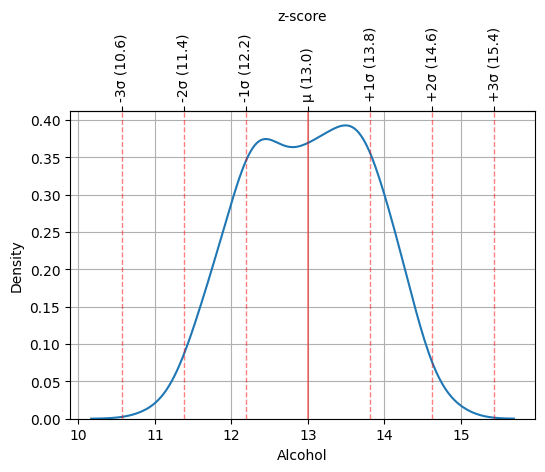

In [27]:
num_column_analysis(dataset['alcohol'], 'Alcohol')

##### malic_acid

Frequency Table for the Column 'Malic acid'

            Frequencies  Cumulative Frequencies  Percentages  \
malic_acid                                                     
1.73                  7                       7     3.932584   
1.81                  4                      11     2.247191   
1.67                  4                      15     2.247191   
1.35                  3                      18     1.685393   
1.90                  3                      21     1.685393   
...                 ...                     ...          ...   
2.51                  1                     174     0.561798   
5.65                  1                     175     0.561798   
3.91                  1                     176     0.561798   
4.28                  1                     177     0.561798   
4.10                  1                     178     0.561798   

            Cumulative Percentages  
malic_acid                          
1.73                      3.932584  
1.81       

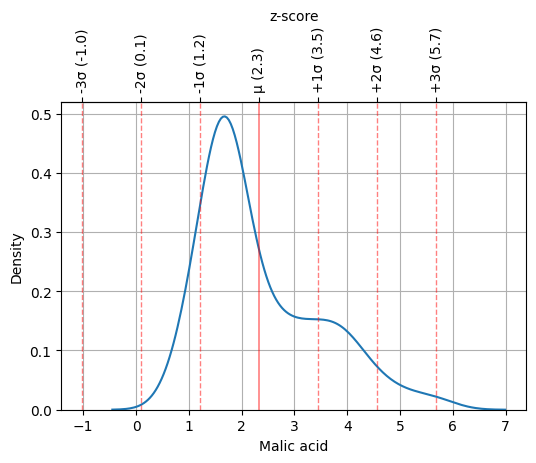

In [29]:
num_column_analysis(dataset['malic_acid'], 'Malic acid')

##### ash

Frequency Table for the Column 'Ash'

      Frequencies  Cumulative Frequencies  Percentages  Cumulative Percentages
ash                                                                           
2.30            7                       7     3.932584                3.932584
2.28            7                      14     3.932584                7.865169
2.32            6                      20     3.370787               11.235955
2.36            6                      26     3.370787               14.606742
2.70            6                      32     3.370787               17.977528
...           ...                     ...          ...                     ...
2.15            1                     174     0.561798               97.752809
2.75            1                     175     0.561798               98.314607
2.69            1                     176     0.561798               98.876404
2.86            1                     177     0.561798               99.438202
2.37          

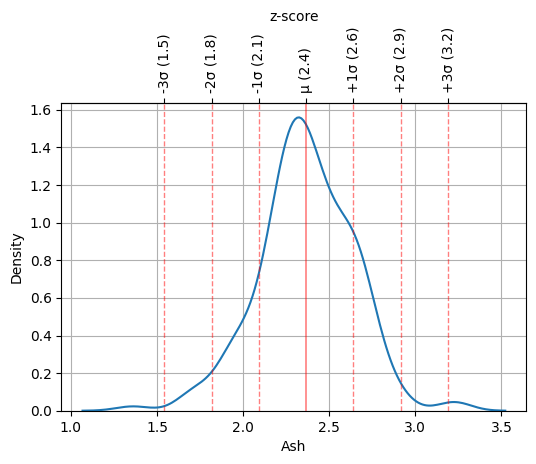

In [30]:
num_column_analysis(dataset['ash'], 'Ash')

##### alcalinity_of_ash

Frequency Table for the Column 'Alcalinity of ash'

                   Frequencies  Cumulative Frequencies  Percentages  \
alcalinity_of_ash                                                     
20.0                        15                      15     8.426966   
16.0                        11                      26     6.179775   
21.0                        11                      37     6.179775   
18.0                        10                      47     5.617978   
19.0                         9                      56     5.056180   
...                        ...                     ...          ...   
20.8                         1                     174     0.561798   
26.5                         1                     175     0.561798   
23.5                         1                     176     0.561798   
25.5                         1                     177     0.561798   
27.0                         1                     178     0.561798   

                   Cumul

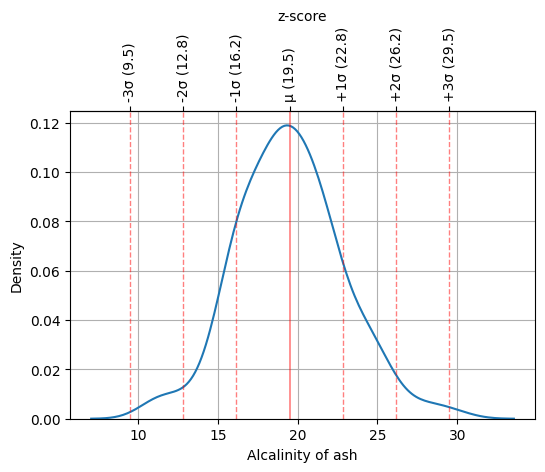

In [31]:
num_column_analysis(dataset['alcalinity_of_ash'], 'Alcalinity of ash')

##### magnesium

Frequency Table for the Column 'Magnesium'

           Frequencies  Cumulative Frequencies  Percentages  \
magnesium                                                     
88.0                13                      13     7.303371   
86.0                11                      24     6.179775   
101.0                9                      33     5.056180   
98.0                 9                      42     5.056180   
96.0                 8                      50     4.494382   
102.0                7                      57     3.932584   
85.0                 6                      63     3.370787   
94.0                 6                      69     3.370787   
112.0                6                      75     3.370787   
89.0                 5                      80     2.808989   
97.0                 5                      85     2.808989   
80.0                 5                      90     2.808989   
103.0                5                      95     2.808989   
92.0       

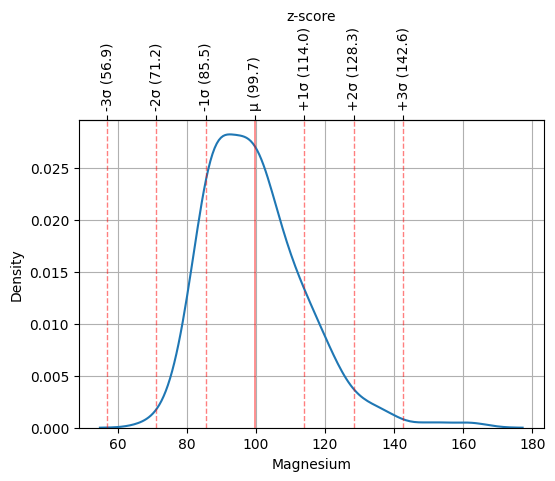

In [32]:
num_column_analysis(dataset['magnesium'], 'Magnesium')

##### total_phenols

Frequency Table for the Column 'Total phenols'

               Frequencies  Cumulative Frequencies  Percentages  \
total_phenols                                                     
2.20                     8                       8     4.494382   
2.80                     6                      14     3.370787   
2.60                     6                      20     3.370787   
3.00                     6                      26     3.370787   
2.95                     5                      31     2.808989   
...                    ...                     ...          ...   
1.83                     1                     174     0.561798   
1.35                     1                     175     0.561798   
1.28                     1                     176     0.561798   
1.25                     1                     177     0.561798   
1.59                     1                     178     0.561798   

               Cumulative Percentages  
total_phenols                          


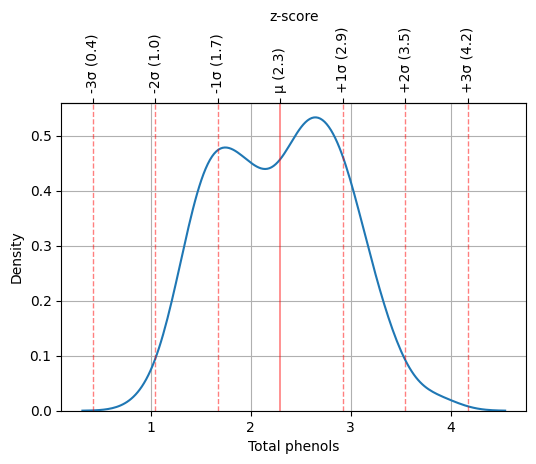

In [33]:
num_column_analysis(dataset['total_phenols'], 'Total phenols')

##### flavanoids

Frequency Table for the Column 'Flavanoids'

            Frequencies  Cumulative Frequencies  Percentages  \
flavanoids                                                     
2.65                  4                       4     2.247191   
1.25                  3                       7     1.685393   
2.68                  3                      10     1.685393   
2.03                  3                      13     1.685393   
0.58                  3                      16     1.685393   
...                 ...                     ...          ...   
0.49                  1                     174     0.561798   
0.51                  1                     175     0.561798   
0.61                  1                     176     0.561798   
0.75                  1                     177     0.561798   
0.69                  1                     178     0.561798   

            Cumulative Percentages  
flavanoids                          
2.65                      2.247191  
1.25       

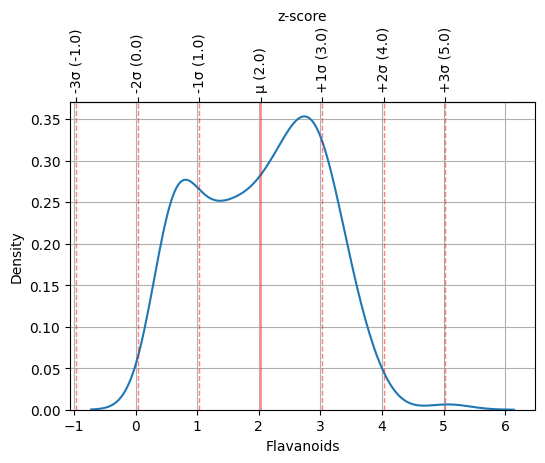

In [34]:
num_column_analysis(dataset['flavanoids'], 'Flavanoids')

##### nonflavanoid_phenols

Frequency Table for the Column 'Nonflavanoid phenols'

                      Frequencies  Cumulative Frequencies  Percentages  \
nonflavanoid_phenols                                                     
0.26                           11                      11     6.179775   
0.43                           11                      22     6.179775   
0.29                           10                      32     5.617978   
0.32                            9                      41     5.056180   
0.40                            8                      49     4.494382   
0.30                            8                      57     4.494382   
0.34                            8                      65     4.494382   
0.37                            8                      73     4.494382   
0.27                            8                      81     4.494382   
0.53                            7                      88     3.932584   
0.24                            7                      95

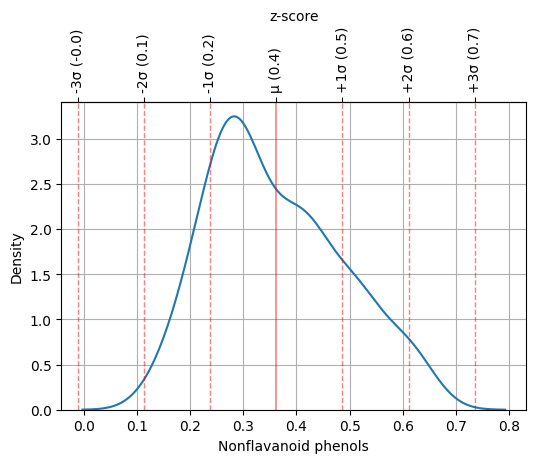

In [35]:
num_column_analysis(dataset['nonflavanoid_phenols'], 'Nonflavanoid phenols')

##### proanthocyanins

Frequency Table for the Column 'Proanthocyanins'

                 Frequencies  Cumulative Frequencies  Percentages  \
proanthocyanins                                                     
1.35                       9                       9     5.056180   
1.46                       7                      16     3.932584   
1.87                       6                      22     3.370787   
1.25                       5                      27     2.808989   
1.66                       4                      31     2.247191   
...                      ...                     ...          ...   
0.97                       1                     174     0.561798   
1.11                       1                     175     0.561798   
1.24                       1                     176     0.561798   
1.06                       1                     177     0.561798   
1.41                       1                     178     0.561798   

                 Cumulative Percentages  
proanthocy

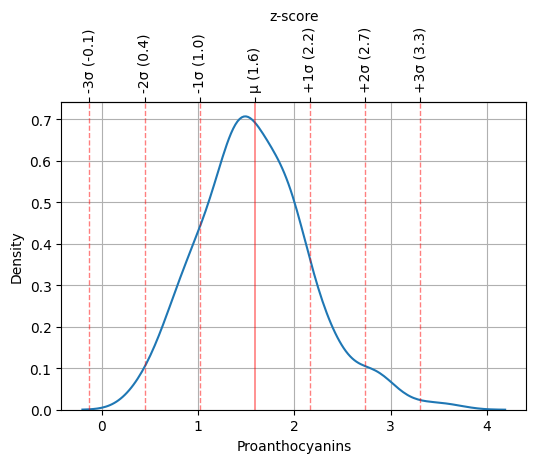

In [36]:
num_column_analysis(dataset['proanthocyanins'], 'Proanthocyanins')

##### color_intensity

Frequency Table for the Column 'Color intensity'

                 Frequencies  Cumulative Frequencies  Percentages  \
color_intensity                                                     
3.8                        4                       4     2.247191   
2.6                        4                       8     2.247191   
4.6                        4                      12     2.247191   
5.0                        3                      15     1.685393   
3.4                        3                      18     1.685393   
...                      ...                     ...          ...   
9.7                        1                     174     0.561798   
7.7                        1                     175     0.561798   
10.2                       1                     176     0.561798   
9.3                        1                     177     0.561798   
9.2                        1                     178     0.561798   

                 Cumulative Percentages  
color_inte

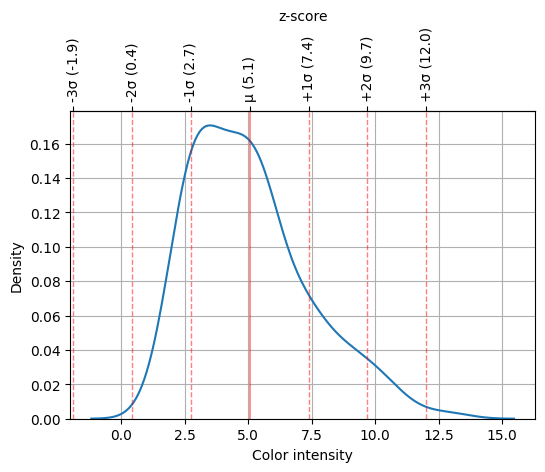

In [37]:
num_column_analysis(dataset['color_intensity'], 'Color intensity')

##### hue

Frequency Table for the Column 'Hue'

      Frequencies  Cumulative Frequencies  Percentages  Cumulative Percentages
hue                                                                           
1.04            8                       8     4.494382                4.494382
1.23            7                      15     3.932584                8.426966
1.12            6                      21     3.370787               11.797753
0.96            5                      26     2.808989               14.606742
0.89            5                      31     2.808989               17.415730
...           ...                     ...          ...                     ...
0.68            1                     174     0.561798               97.752809
0.85            1                     175     0.561798               98.314607
0.72            1                     176     0.561798               98.876404
0.62            1                     177     0.561798               99.438202
0.64          

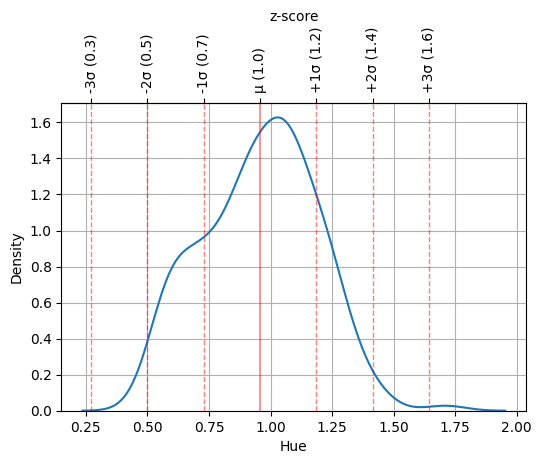

In [38]:
num_column_analysis(dataset['hue'], 'Hue')

##### od280/od315_of_diluted_wines

Frequency Table for the Column 'OD280/OD315 of diluted wines'

                              Frequencies  Cumulative Frequencies  \
od280/od315_of_diluted_wines                                        
2.87                                    5                       5   
3.00                                    4                       9   
2.78                                    4                      13   
1.82                                    4                      17   
2.77                                    3                      20   
...                                   ...                     ...   
1.83                                    1                     174   
1.63                                    1                     175   
1.71                                    1                     176   
1.74                                    1                     177   
1.60                                    1                     178   

                              Percentag

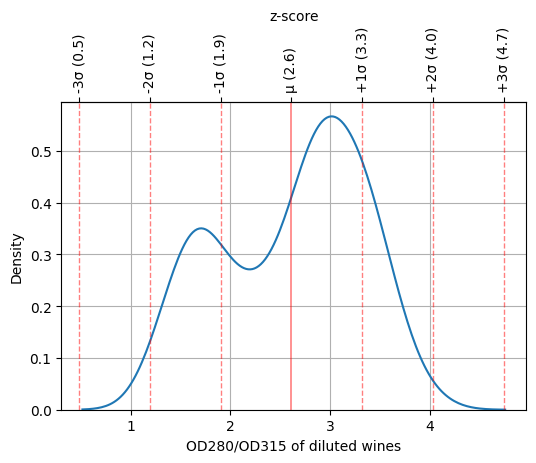

In [42]:
num_column_analysis(dataset['od280/od315_of_diluted_wines'], 'OD280/OD315 of diluted wines')

##### proline

Frequency Table for the Column 'Proline'

         Frequencies  Cumulative Frequencies  Percentages  \
proline                                                     
680.0              5                       5     2.808989   
520.0              5                      10     2.808989   
630.0              4                      14     2.247191   
750.0              4                      18     2.247191   
625.0              4                      22     2.247191   
...              ...                     ...          ...   
685.0              1                     174     0.561798   
470.0              1                     175     0.561798   
740.0              1                     176     0.561798   
835.0              1                     177     0.561798   
840.0              1                     178     0.561798   

         Cumulative Percentages  
proline                          
680.0                  2.808989  
520.0                  5.617978  
630.0                  7.865

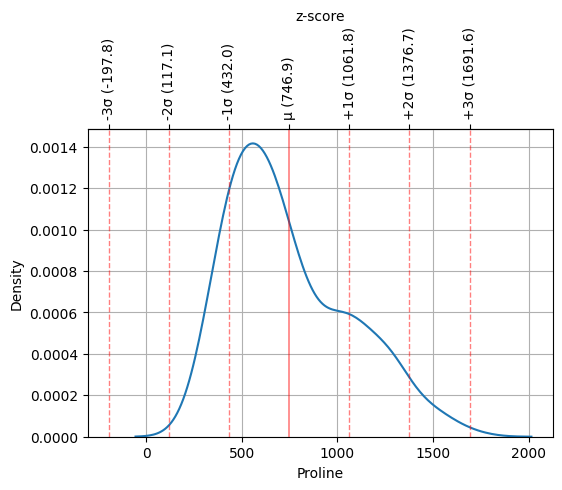

In [43]:
num_column_analysis(dataset['proline'], 'Proline')

### The Label

Frequency Table for the Column 'Target (Wine Class)'

         Frequencies  Cumulative Frequencies  Percentages  \
target                                                      
Class 0           59                      59    33.146067   
Class 1           71                     130    39.887640   
Class 2           48                     178    26.966292   

         Cumulative Percentages  
target                           
Class 0               33.146067  
Class 1               73.033708  
Class 2              100.000000  


Central Tendencies of the Column 'Target (Wine Class)'

Mode: 'Class 1'
Median: 'Class 1' and 'Class 1'


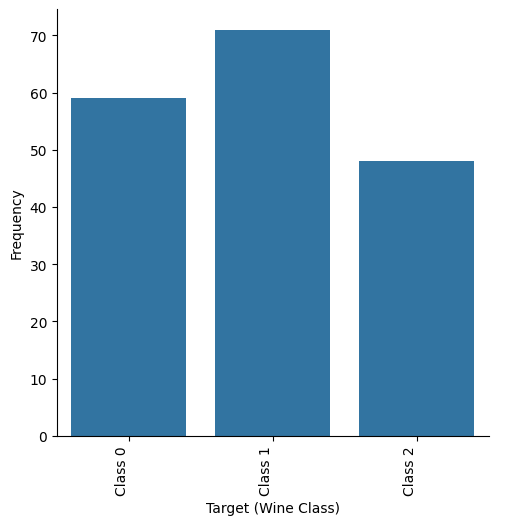

In [44]:
label_domain = ['Class 0', 'Class 1', 'Class 2']
label = dataset['target'].astype(pd.CategoricalDtype(categories=[0, 1, 2], ordered=True)).cat.rename_categories(label_domain)

cat_column_analysis(label, 'Target (Wine Class)')

# Feature-Target Separation

In [45]:
X = dataset.drop('target', axis=1)
y = dataset['target']

# Train-Test Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Pipeline

In [47]:
knn_pipeline = Pipeline([
    ('standard_scaling', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# HyperParameter Tuning

In [49]:
grid_params = {
    "knn__n_neighbors": range(1, 16, 2),
    "knn__weights": ['uniform', 'distance'],
    'knn__p' : [1, 2]
}

grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=grid_params,
    cv=5
)

In [50]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standard_scaling', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': range(1, 16, 2), 'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']})

# Best Model

In [51]:
print(f"The best Value of k is {grid.best_params_['knn__n_neighbors']}")

The best Value of k is 5


In [52]:
print(f"The best weight is {grid.best_params_['knn__weights']}")

The best weight is uniform


In [60]:
print(f"The best distance metric is {['Euclidean', 'Manhattan'][grid.best_params_['knn__p']]}")

The best distance metric is Manhattan


In [53]:
best_knn_model = grid.best_estimator_

# Test

In [54]:
y_test_pred = best_knn_model.predict(X_test)

In [55]:
print(accuracy_score(y_test, y_test_pred))

0.9444444444444444


In [56]:
my_confusion_matrix = confusion_matrix(y_test, y_test_pred)

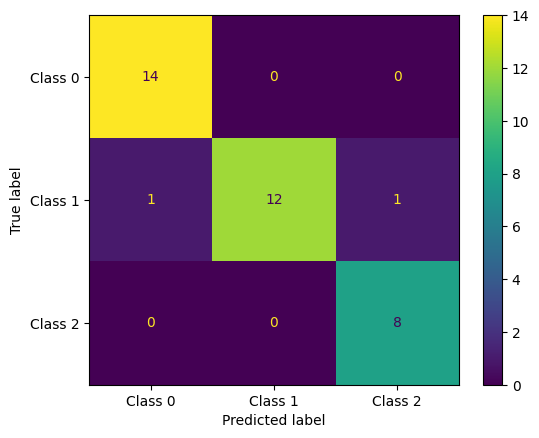

In [58]:
cm_display = ConfusionMatrixDisplay(my_confusion_matrix, display_labels=label_domain)

cm_display.plot()



In [59]:
print(classification_report(y_test, y_test_pred, target_names=label_domain))

              precision    recall  f1-score   support

     Class 0       0.93      1.00      0.97        14
     Class 1       1.00      0.86      0.92        14
     Class 2       0.89      1.00      0.94         8

    accuracy                           0.94        36
   macro avg       0.94      0.95      0.94        36
weighted avg       0.95      0.94      0.94        36

